In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import re

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score

In [2]:
data = {
    "Review": [
        "This movie was excellent",
        "I enjoyed watching this movie",
        "The movie was boring",
        "Worst movie ever",
        "Movie was average",
        "It was okay",
        "Fantastic acting",
        "Poor storyline"
    ],

    "Sentiment": [
        "Positive",
        "Positive",
        "Negative",
        "Negative",
        "Neutral",
        "Neutral",
        "Positive",
        "Negative"
    ]
}

reviews = pd.DataFrame(data)

print("Movie Reviews Dataset")
print(reviews)


Movie Reviews Dataset
                          Review Sentiment
0       This movie was excellent  Positive
1  I enjoyed watching this movie  Positive
2           The movie was boring  Negative
3               Worst movie ever  Negative
4              Movie was average   Neutral
5                    It was okay   Neutral
6               Fantastic acting  Positive
7                 Poor storyline  Negative


In [3]:
def clean_text(text):

    # convert to lowercase
    text = text.lower()

    # remove symbols
    text = re.sub(r'[^a-z ]', '', text)

    return text


reviews["Clean_Review"] = reviews["Review"].apply(clean_text)

print("\nAfter Cleaning")
print(reviews)



After Cleaning
                          Review Sentiment                   Clean_Review
0       This movie was excellent  Positive       this movie was excellent
1  I enjoyed watching this movie  Positive  i enjoyed watching this movie
2           The movie was boring  Negative           the movie was boring
3               Worst movie ever  Negative               worst movie ever
4              Movie was average   Neutral              movie was average
5                    It was okay   Neutral                    it was okay
6               Fantastic acting  Positive               fantastic acting
7                 Poor storyline  Negative                 poor storyline


In [4]:
vector = TfidfVectorizer()
X = vector.fit_transform(reviews["Clean_Review"])
y = reviews["Sentiment"]

In [5]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [6]:
model = LogisticRegression()

model.fit(X_train, y_train)

LogisticRegression()

In [7]:
prediction = model.predict(X_test)

accuracy = accuracy_score(
    y_test,
    prediction
)

print("\nAccuracy:")
print(round(accuracy * 100, 2), "%")


Accuracy:
0.0 %


In [8]:
user_review = input(
    "\nEnter Movie Review: "
)

new_review = clean_text(
    user_review
)

review_vector = vector.transform(
    [new_review]
)

result = model.predict(
    review_vector
)

print("\nPredicted Sentiment:")
print(result[0])


Enter Movie Review: 4

Predicted Sentiment:
Negative


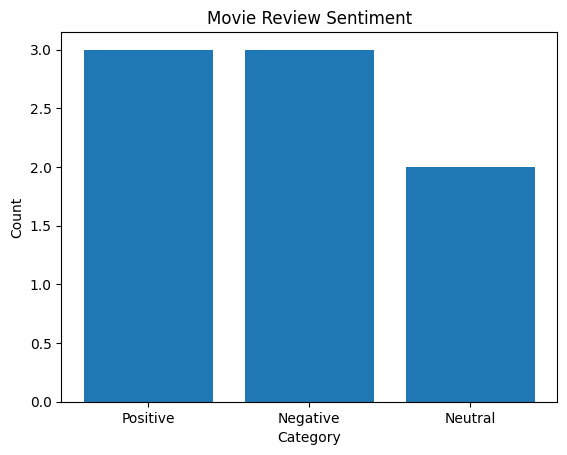

In [9]:
count = reviews["Sentiment"].value_counts()

plt.bar(
    count.index,
    count.values
)

plt.title(
    "Movie Review Sentiment"
)

plt.xlabel(
    "Category"
)

plt.ylabel(
    "Count"
)

plt.show()